In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [20]:
df["attrition_flag"] = df["Attrition"].map({"No": 0, "Yes": 1})
df.attrition_flag.value_counts()

attrition_flag
0    1233
1     237
Name: count, dtype: int64

In [21]:
df.attrition_flag.mean()

np.float64(0.16122448979591836)

In [22]:
# 결측치 확인
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

In [23]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

C:\Users\hissc\AppData\Local\Temp\ipykernel_31660\2045601431.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [24]:
print("num_cols:",len(num_cols),"/ cat_cols:", len(cat_cols))

num_cols: 27 / cat_cols: 9


In [25]:
# 범주형 변수별 이직률
key_cat_cols = ["OverTime", "JobRole", "MaritalStatus", "BusinessTravel", "Department"]
for col in key_cat_cols:
    result = (
        df.groupby(col)["attrition_flag"]
        .agg(["mean","count"])
        .sort_values("mean", ascending=False)
    )
    print(f"\n{col}별 이직률:")
    print(result)


OverTime별 이직률:
              mean  count
OverTime                 
Yes       0.305288    416
No        0.104364   1054

JobRole별 이직률:
                               mean  count
JobRole                                   
Sales Representative       0.397590     83
Laboratory Technician      0.239382    259
Human Resources            0.230769     52
Sales Executive            0.174847    326
Research Scientist         0.160959    292
Manufacturing Director     0.068966    145
Healthcare Representative  0.068702    131
Manager                    0.049020    102
Research Director          0.025000     80

MaritalStatus별 이직률:
                   mean  count
MaritalStatus                 
Single         0.255319    470
Married        0.124814    673
Divorced       0.100917    327

BusinessTravel별 이직률:
                       mean  count
BusinessTravel                    
Travel_Frequently  0.249097    277
Travel_Rarely      0.149569   1043
Non-Travel         0.080000    150

Department별 이직률:
 

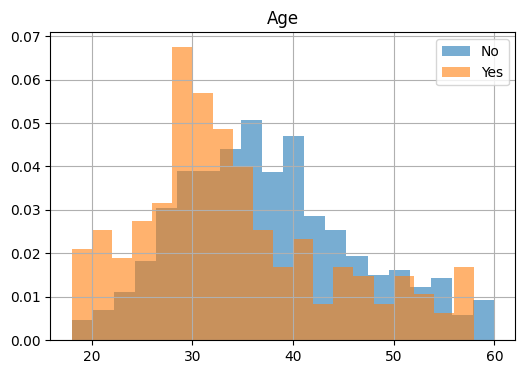

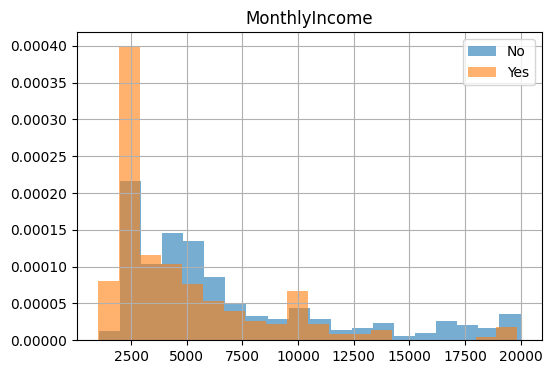

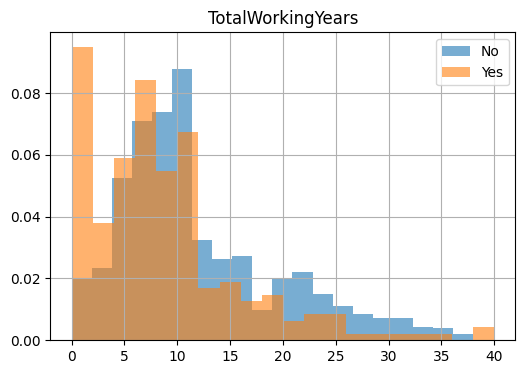

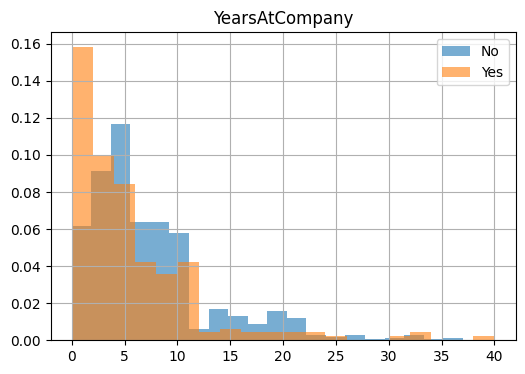

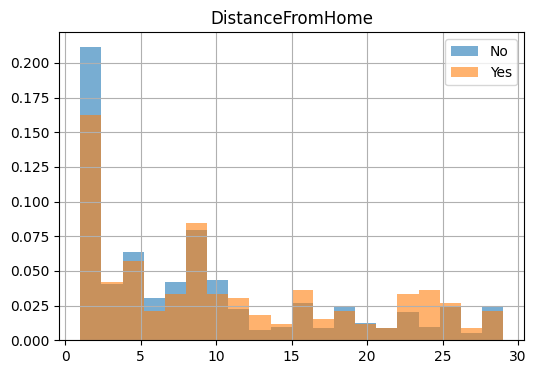

In [26]:
# 수치형 변수의 이직/비이직 비교
# 직관적으로 이직과 관련성 높아 보이는 변수 임의 선정 
key_num_cols = ["Age", "MonthlyIncome", "TotalWorkingYears", "YearsAtCompany", "DistanceFromHome"]

for col in key_num_cols:
    plt.figure(figsize=(6, 4))
    df[df["attrition_flag"] == 0][col].hist(alpha=0.6, bins=20, label="No", density=True)
    df[df["attrition_flag"] == 1][col].hist(alpha=0.6, bins=20, label="Yes", density=True)
    plt.title(col)
    plt.legend()
    plt.show()

<Figure size 600x400 with 0 Axes>

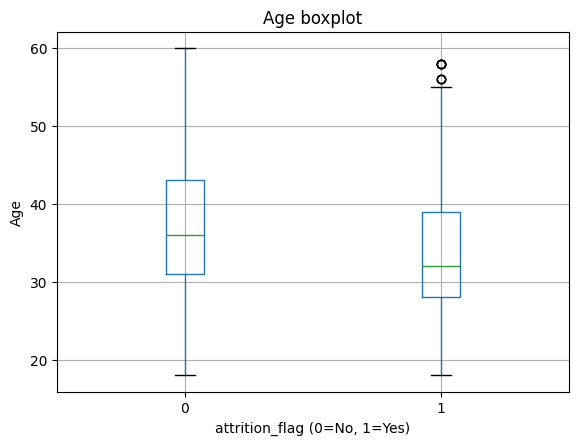

<Figure size 600x400 with 0 Axes>

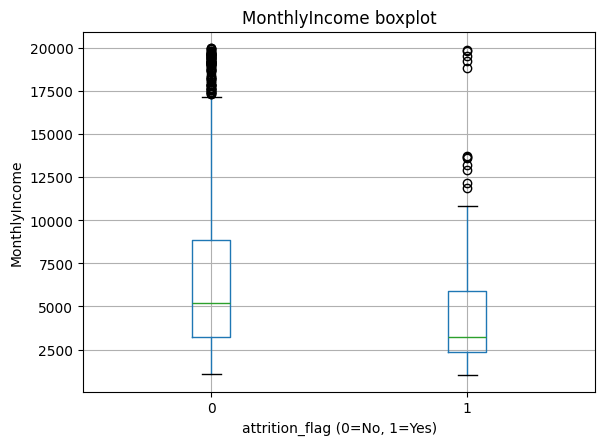

<Figure size 600x400 with 0 Axes>

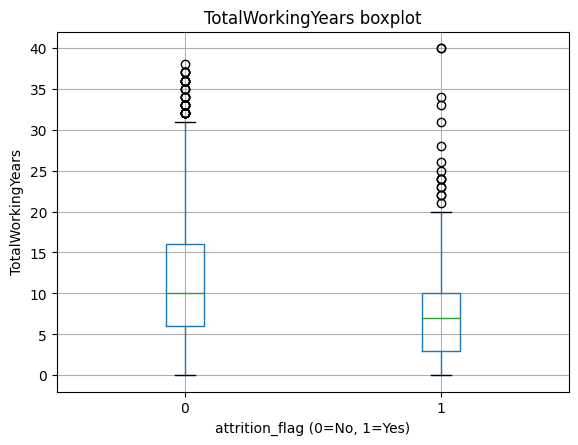

<Figure size 600x400 with 0 Axes>

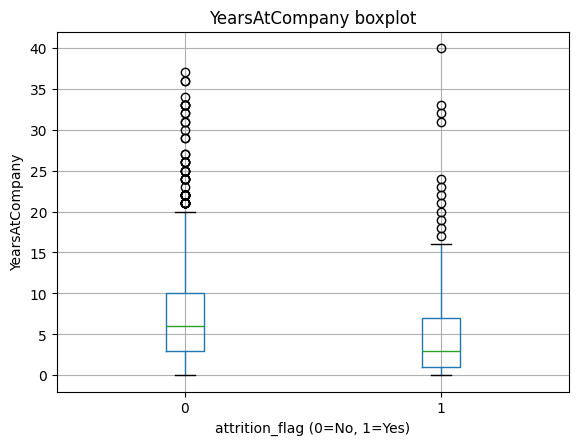

<Figure size 600x400 with 0 Axes>

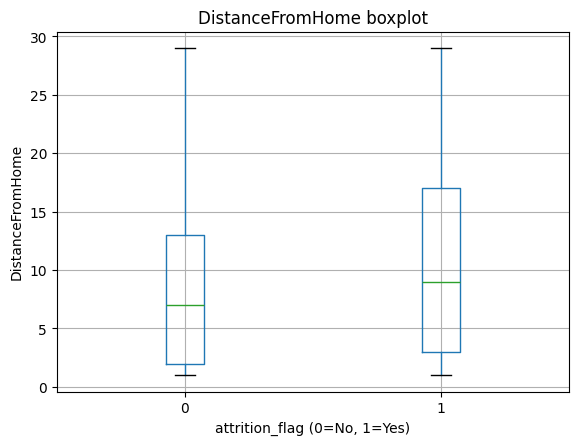

In [27]:
for col in key_num_cols:
    plt.figure(figsize=(6,4))
    df.boxplot(column=col, by="attrition_flag")
    plt.title(f"{col} boxplot")
    plt.suptitle("")
    plt.xlabel("attrition_flag (0=No, 1=Yes)")
    plt.ylabel(col)
    plt.show()

- 전체 이직률 : 약 16.1%
- 초과근무시 이직률이 더 높게 나타남
- 영업직 등 특정 직무의 이직률이 상대적으로 높음
- 연령과 재직기간이 낮은 구간에서 이직 비중이 높게 나타남
- 향후 분석에서 개인 특성 및 직무, 근무강도, 근속기간 관련 변수 함께 고려 필요